# Supplementary Fig. 26 — performance of the unphased mCA caller on simulated test data

Six-panel evaluation of the TETRIS-seq **unphased** mCA caller against a simulated test set (9 samples,
12,306 ground-truth events; a factorial design of 14 cell fractions × 3 mCA types × event sizes 2 Mb → whole-arm;
7,854 events ≥5 Mb). A call is a true positive if it matches the truth event on chromosome, type and location
(≥50% overlap); events on event-free chromosomes are false positives; undetected truth events are false negatives.

- **a** sensitivity vs cell fraction stratified by event size (all sizes)
- **b** overall sensitivity vs cell fraction (≥5 Mb)  — 96.4% at 100% CF, 57.9% at 25% CF
- **c** sensitivity by mCA type (≥5 Mb)
- **d** sensitivity by event geometry (≥5 Mb)
- **e** precision (PPV, left axis) and false positives / sample (right axis) (≥5 Mb)
- **f** sensitivity heatmap by chromosome × cell fraction (≥5 Mb, ≥10% CF)

This notebook produces the published 6-panel figure directly.


The table is produced by `Supplementary_Fig_26_mCA_caller_on_simulated_samples.py`, which runs the
unphased caller over the simulated samples and matches each call against the ground truth.

## Data availability
This notebook reads one **simulated** per-event outcome table,
`Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/truth_comparison.csv` — the caller-vs-ground-truth comparison for the
test set (produced once by running the unphased mCA caller over the simulated samples; not re-run here).


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
grey3 = '#969696'  # axis / spine colour used by the panels

## 2. Load the simulated test-set outcomes (cache)

In [2]:
# Per-event caller-vs-truth outcomes for the simulated TEST set
df = pd.read_csv('Data_files/mCA_calling/Simulated_data/mCA_simulation_test_set/truth_comparison.csv')

def categorize_length(row):
    if row['Truth_Geometry'] == 'Whole_Arm':
        return 'WholeArm'
    L = row['Truth_Length_Mb']
    if L < 2.5:  return '2Mb'
    if L < 3.5:  return '3Mb'
    if L < 7.5:  return '5Mb'
    if L < 15:   return '10Mb'
    return '20Mb'
df['Truth_Length_Category'] = df.apply(categorize_length, axis=1)

# panel a uses all sizes; panels b-f use events >= 5 Mb (within the panel's effective resolution)
df_5mb = df[df['Truth_Length_Category'].isin(['5Mb', '10Mb', '20Mb', 'WholeArm'])]
print(f'all events: {len(df)} | >=5Mb: {len(df_5mb)} | cell fractions: {df["Truth_Fraction"].nunique()}')

all events: 12306 | >=5Mb: 7854 | cell fractions: 14


## 3. Metric helpers

In [3]:
def calculate_metrics(df):
    """Calculate sensitivity, precision, and other metrics"""
    total = len(df)
    detected = df['Detected'].sum()
    missed = total - detected
    fp_count = df['False_Positives'].sum() if 'False_Positives' in df.columns else 0
    
    sensitivity = detected / total if total > 0 else 0
    precision = detected / (detected + fp_count) if (detected + fp_count) > 0 else 0
    fdr = fp_count / (detected + fp_count) if (detected + fp_count) > 0 else 0
    fp_per_sample = fp_count / total if total > 0 else 0
    
    return {
        'Total': total,
        'True_Positives': detected,
        'False_Negatives': missed,
        'False_Positives': fp_count,
        'Sensitivity': sensitivity,
        'Precision': precision,
        'FP_per_sample': fp_per_sample,
        'FDR': fdr
    }

In [5]:
def metrics_by_group(df, group_col, group_label):
    """Calculate metrics for each group"""
    results = []
    for group in sorted(df[group_col].unique()):
        group_df = df[df[group_col] == group]
        metrics = calculate_metrics(group_df)
        metrics[group_label] = group
        results.append(metrics)
    return pd.DataFrame(results)

## 4. The combined 6-panel figure (a–f)

In [6]:
def plot_combined_sensitivity_figure(df_all, df_5mb):

    import matplotlib as mpl
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42

    # ── font constants ──────────────────────────────────────────────────────
    SZ     = 10    # body: axis labels, tick labels, legends, annotations
    SZ_TTL = 12   # panel titles
    SZ_LBL = 13   # bold panel letters (a, b, c …)

    fig = plt.figure(figsize=(22, 10))
    gs  = gridspec.GridSpec(
        2, 4,
        figure=fig,
        hspace=0.38, wspace=0.35,
        height_ratios=[1, 1.05],
    )

    # ── helpers ─────────────────────────────────────────────────────────────
    def _style(ax):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for sp in ['bottom', 'left']:
            ax.spines[sp].set_linewidth(1.5)
            ax.spines[sp].set_color(grey3)
        ax.xaxis.set_tick_params(width=1, color=grey3, length=5)
        ax.yaxis.set_tick_params(width=1, color=grey3, length=5)
        ax.tick_params(labelsize=SZ)
        ax.xaxis.label.set_fontsize(SZ)
        ax.yaxis.label.set_fontsize(SZ)
        ax.title.set_fontsize(SZ_TTL)

    panel_labels = iter('abcdef')

    def _label(ax):
        ax.text(-0.12, 1.05, next(panel_labels),
                transform=ax.transAxes, fontsize=SZ_LBL,
                fontweight='bold', va='top', ha='left')

    # ── Panel a: Sensitivity by event size (ALL sizes) ──────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    size_order  = ['2Mb', '3Mb', '5Mb', '10Mb', '20Mb', 'WholeArm']
    size_colors = ['#E63946', '#F77F00', '#FCBF49', '#06A77D', '#2E86AB', '#7B2D8E']
    for size, color in zip(size_order, size_colors):
        sub = df_all[df_all['Truth_Length_Category'] == size]
        if len(sub) == 0:
            continue
        fm = metrics_by_group(sub, 'Truth_Fraction', 'Fraction')
        fm['Fraction_Pct'] = fm['Fraction'] * 100
        ax_a.plot(fm['Fraction_Pct'], fm['Sensitivity'] * 100,
                  'o-', linewidth=2, markersize=6, label=size, color=color)
    ax_a.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.set_xlabel('Cell Fraction (%)', fontsize=SZ, fontweight='bold')
    ax_a.set_ylabel('Sensitivity (%)', fontsize=SZ, fontweight='bold')
    ax_a.set_title('Sensitivity by Event Size', fontsize=SZ_TTL, fontweight='bold')
    ax_a.set_ylim(-5, 105)
    ax_a.legend(frameon=True, fontsize=SZ, loc='upper left')
    ax_a.grid(True, alpha=0.3)
    _style(ax_a); _label(ax_a)

    # ── Panel b: Overall sensitivity vs CF (≥5 Mb) ──────────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    fm_b = metrics_by_group(df_5mb, 'Truth_Fraction', 'Fraction')
    fm_b['Fraction_Pct'] = fm_b['Fraction'] * 100
    ax_b.plot(fm_b['Fraction_Pct'], fm_b['Sensitivity'] * 100,
              'o-', linewidth=2, markersize=8, color='#2E86AB')
    ax_b.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1,
                 label='50% sensitivity')
    for _, row in fm_b.iterrows():
        if row['Sensitivity'] > 0.01:
            ax_b.text(row['Fraction_Pct'], row['Sensitivity'] * 100 + 3,
                      f"{int(row['True_Positives'])}/{int(row['Total'])}",
                      ha='center', fontsize=SZ, fontweight='bold')
    ax_b.set_xlabel('Cell Fraction (%)', fontsize=SZ, fontweight='bold')
    ax_b.set_ylabel('Sensitivity (%)', fontsize=SZ, fontweight='bold')
    ax_b.set_title('Overall Sensitivity vs Cell Fraction', fontsize=SZ_TTL, fontweight='bold')
    ax_b.set_ylim(-5, 105)
    ax_b.legend(fontsize=SZ)
    ax_b.grid(True, alpha=0.3)
    _style(ax_b); _label(ax_b)

    # ── Panel c: Sensitivity by event type (≥5 Mb) ──────────────────────────
    ax_c = fig.add_subplot(gs[0, 2])
    type_colors = {'CNLOH': '#2E86AB', 'GAIN': '#F77F00', 'LOSS': '#06A77D'}
    for etype in sorted(df_5mb['Truth_Type'].unique()):
        sub = df_5mb[df_5mb['Truth_Type'] == etype]
        fm  = metrics_by_group(sub, 'Truth_Fraction', 'Fraction')
        fm['Fraction_Pct'] = fm['Fraction'] * 100
        ax_c.plot(fm['Fraction_Pct'], fm['Sensitivity'] * 100,
                  'o-', linewidth=2, markersize=6,
                  label=etype, color=type_colors.get(etype, '#888888'))
    ax_c.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_c.set_xlabel('Cell Fraction (%)', fontsize=SZ, fontweight='bold')
    ax_c.set_ylabel('Sensitivity (%)', fontsize=SZ, fontweight='bold')
    ax_c.set_title('Sensitivity by Event Type', fontsize=SZ_TTL, fontweight='bold')
    ax_c.set_ylim(-5, 105)
    ax_c.legend(frameon=True, fontsize=SZ)
    ax_c.grid(True, alpha=0.3)
    _style(ax_c); _label(ax_c)

    # ── Panel d: Sensitivity by geometry (≥5 Mb) ────────────────────────────
    ax_d = fig.add_subplot(gs[0, 3])
    geom_colors = {'Interstitial': '#2E86AB', 'Telomeric': '#F77F00', 'Whole_Arm': '#06A77D'}
    for geom in sorted(df_5mb['Truth_Geometry'].unique()):
        sub = df_5mb[df_5mb['Truth_Geometry'] == geom]
        fm  = metrics_by_group(sub, 'Truth_Fraction', 'Fraction')
        fm['Fraction_Pct'] = fm['Fraction'] * 100
        ax_d.plot(fm['Fraction_Pct'], fm['Sensitivity'] * 100,
                  'o-', linewidth=2, markersize=6,
                  label=geom, color=geom_colors.get(geom, '#888888'))
    ax_d.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_d.set_xlabel('Cell Fraction (%)', fontsize=SZ, fontweight='bold')
    ax_d.set_ylabel('Sensitivity (%)', fontsize=SZ, fontweight='bold')
    ax_d.set_title('Sensitivity by Geometry', fontsize=SZ_TTL, fontweight='bold')
    ax_d.set_ylim(-5, 105)
    ax_d.legend(frameon=True, fontsize=SZ)
    ax_d.grid(True, alpha=0.3)
    _style(ax_d); _label(ax_d)

    # ── Panel e: Precision + FP/sample twin-axis (≥5 Mb) ────────────────────
    ax_e = fig.add_subplot(gs[1, 0])
    fm_e = metrics_by_group(df_5mb, 'Truth_Fraction', 'Fraction')
    fm_e['Fraction_Pct'] = fm_e['Fraction'] * 100
    prec_color = '#06A77D'
    fp_color   = '#E63946'

    ax_e.plot(fm_e['Fraction_Pct'], fm_e['Precision'] * 100,
              's-', linewidth=2, markersize=8, color=prec_color,
              label='Precision (PPV)', zorder=3)
    ax_e.axhline(50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax_e.set_xlabel('Cell Fraction (%)', fontsize=SZ, fontweight='bold')
    ax_e.set_ylabel('Precision (PPV) (%)', fontsize=SZ, fontweight='bold', color=prec_color)
    ax_e.tick_params(axis='y', labelcolor=prec_color, labelsize=SZ)
    ax_e.set_ylim(-5, 105)
    ax_e.set_title('Precision & False Positive Rate', fontsize=SZ_TTL, fontweight='bold')
    ax_e.grid(True, alpha=0.3)

    ax_e2 = ax_e.twinx()
    ax_e2.plot(fm_e['Fraction_Pct'], fm_e['FP_per_sample'],
               '^--', linewidth=2, markersize=8, color=fp_color,
               label='FP / sample', zorder=3)
    fp_max = fm_e['FP_per_sample'].max()
    ax_e2.set_ylim(0, max(fp_max * 6, 1.0))
    ax_e2.set_ylabel('False Positives per Sample', fontsize=SZ, fontweight='bold',
                     color=fp_color)
    ax_e2.tick_params(axis='y', labelcolor=fp_color, labelsize=SZ)
    peak_row = fm_e.loc[fm_e['FP_per_sample'].idxmax()]
    ax_e2.annotate(f"peak {peak_row['FP_per_sample']:.2f}",
                   xy=(peak_row['Fraction_Pct'], peak_row['FP_per_sample']),
                   xytext=(peak_row['Fraction_Pct'] + 6,
                           peak_row['FP_per_sample'] * 1.8),
                   fontsize=SZ, fontweight='bold', color=fp_color,
                   arrowprops=dict(arrowstyle='->', color=fp_color, lw=1.0))

    lines1, labs1 = ax_e.get_legend_handles_labels()
    lines2, labs2 = ax_e2.get_legend_handles_labels()
    ax_e.legend(lines1 + lines2, labs1 + labs2,
                frameon=True, fontsize=SZ, loc='center right')

    _style(ax_e)
    ax_e2.spines['top'].set_visible(False)
    ax_e2.spines['right'].set_linewidth(1.5)
    ax_e2.spines['right'].set_color(grey3)
    ax_e2.yaxis.set_tick_params(width=1, color=grey3, length=5)
    _label(ax_e)

    # ── Panel f: Chromosome × CF heatmap (≥5 Mb, ≥10% CF) ──────────────────
    ax_f = fig.add_subplot(gs[1, 1:])

    chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
    detectable  = df_5mb[df_5mb['Truth_Fraction'] >= 0.10]
    pivot = detectable.pivot_table(
        index='Truth_Fraction',
        columns='Truth_Chromosome',
        values='Detected',
        aggfunc='mean'
    ) * 100
    pivot.index = [f"{x*100:.0f}%" for x in pivot.index]
    pivot = pivot.reindex(columns=[c for c in chrom_order if c in pivot.columns])
    pivot.columns = [c.replace('chr', '') for c in pivot.columns]
    pivot = pivot.iloc[::-1]  # highest CF at top

    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlBu',
                vmin=0, vmax=100,
                cbar_kws={'label': 'Sensitivity (%)', 'shrink': 0.8},
                ax=ax_f, linewidths=0.4,
                annot_kws={'size': SZ})
    ax_f.set_title('Sensitivity by Chromosome and Cell Fraction (≥10%)',
                   fontsize=SZ_TTL, fontweight='bold')
    ax_f.set_xlabel('Chromosome', fontsize=SZ, fontweight='bold')
    ax_f.set_ylabel('Cell Fraction', fontsize=SZ, fontweight='bold')
    ax_f.tick_params(axis='both', labelsize=SZ)
    ax_f.set_xticklabels(ax_f.get_xticklabels(), rotation=0)
    ax_f.set_yticklabels(ax_f.get_yticklabels(), rotation=0)
    ax_f.xaxis.set_tick_params(width=1, color=grey3, length=4)
    ax_f.yaxis.set_tick_params(width=1, color=grey3, length=4)

    # Colorbar font
    cbar = ax_f.collections[0].colorbar
    cbar.ax.tick_params(labelsize=SZ)
    cbar.set_label('Sensitivity (%)', fontsize=SZ)

    for sp in ['bottom', 'left', 'top', 'right']:
        ax_f.spines[sp].set_linewidth(1.5)
        ax_f.spines[sp].set_color(grey3)

    ax_f.text(-0.04, 1.05, next(panel_labels),
              transform=ax_f.transAxes, fontsize=SZ_LBL,
              fontweight='bold', va='top', ha='left')

    plt.show()

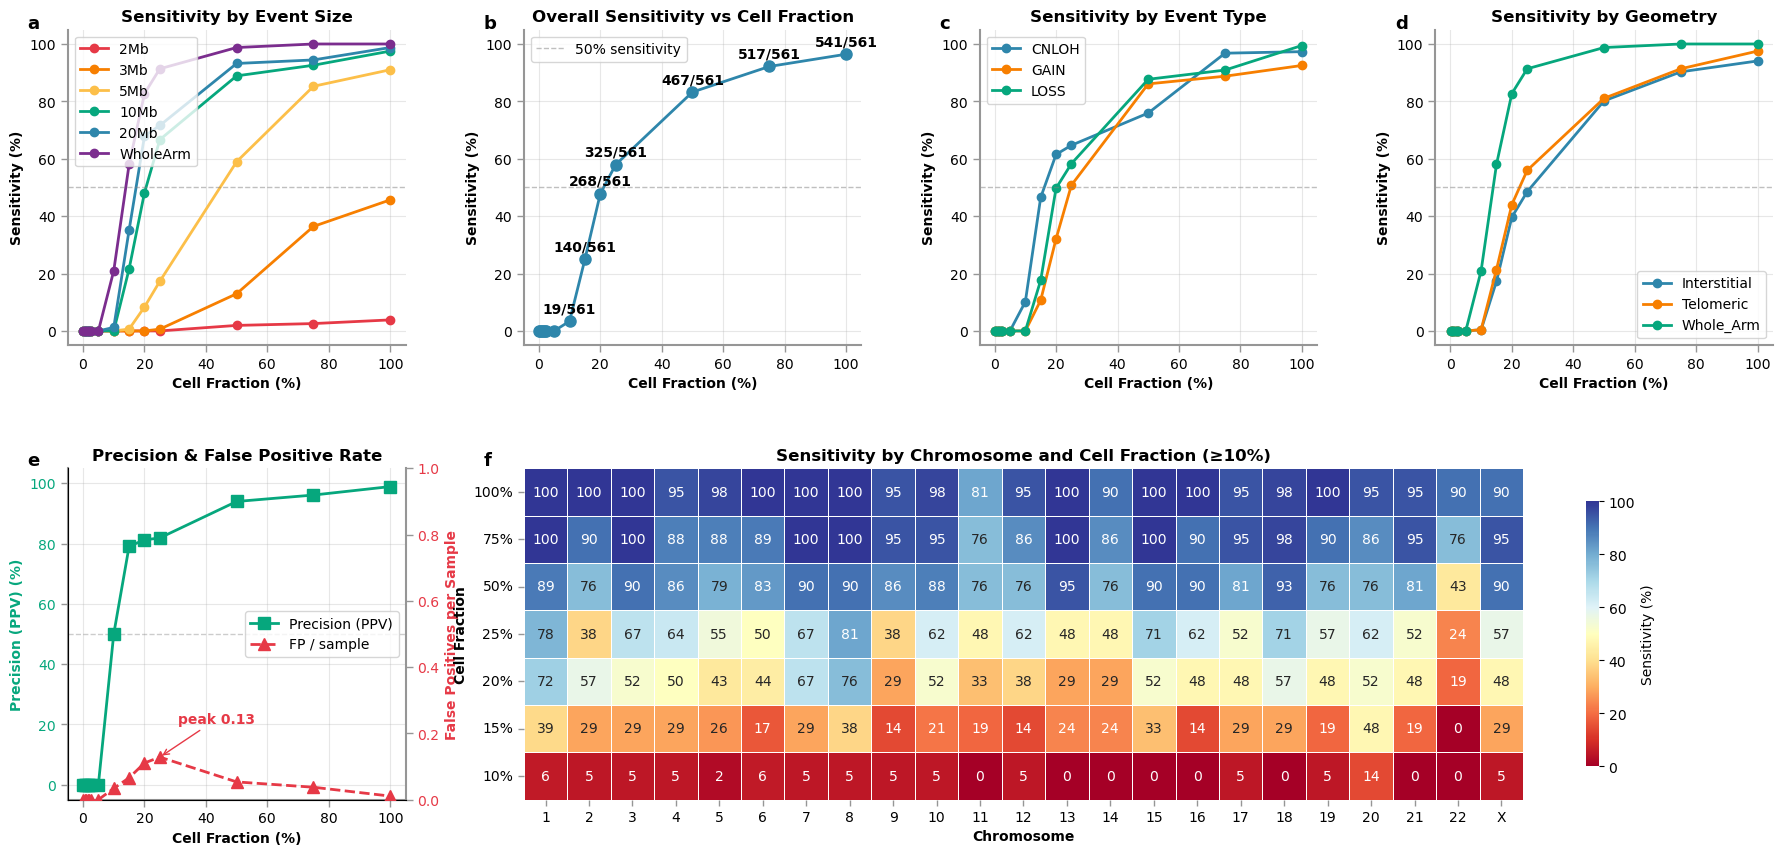

In [7]:
plot_combined_sensitivity_figure(df, df_5mb)